# Banking Channel Performance and Transaction Efficiency Analysis

## 1. Business & Operational Context

- Banks operate through multiple payment channels such as Cash, Card-based payments, E-Wallets, and Online Transfers.
- Optimizing channel performance improves operational cost, customer satisfaction, and transaction efficiency.
- Challenges: high transaction volume, varying costs per transaction, customer behavior differences, risk/fraud exposure.

## 2. Problem Statement

### 2.1 Business Problem

- Identify high-performing channels by volume, value, and efficiency.
- Understand customer behavior per channel.
- Determine channels with higher failure/fraud risk.
- Provide actionable recommendations for channel optimization.

### 2.2 Analytical Questions:

- Transaction distribution across channels (volume & value)?
- Channel efficiency (value vs cost)?
- Customer segment & transaction type patterns per channel?
- Fraud and failed transactions impact channel efficiency?
- How to rank channels for prioritization and investment?

## 3. Dataset Loading & Inspection

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

path = kagglehub.dataset_download("pradeepkumar2424/usa-banking-transactions-dataset-2023-2024")
print(path)

files = os.listdir(path)
print(files)

file_path = os.path.join(path, "Banking_Transactions_USA_2023_2024.csv")
df = pd.read_csv(file_path)

df.head()

/Users/apple/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


100%|██████████| 580k/580k [00:00<00:00, 819kB/s]

Extracting files...
/Users/apple/.cache/kagglehub/datasets/pradeepkumar2424/usa-banking-transactions-dataset-2023-2024/versions/1
['Banking_Transactions_USA_2023_2024.csv']


,Transaction_ID,Account_Number,Transaction_Date,Transaction_Amount,Merchant_Name,Transaction_Type,Category,City,Country,Payment_Method,Customer_Age,Customer_Gender,Customer_Occupation,Customer_Income,Account_Balance,Transaction_Status,Fraud_Flag,Discount_Applied,Loyalty_Points_Earned,Transaction_Description
0,bdd640fb-0667-4ad1-9c80-317fa3b1799d,IUPM04409079772781,2023-11-05 15:54:38,3198.94,Houston Group,Debit,Transport,Phoenix,USA,Online Transfer,55,Others,Quality manager,80466.03,350.28,Failed,No,True,304,Recently company detail form range a.
1,23b8c1e9-3924-46de-beb1-3b9046685257,BLAT22216107051843,2024-04-21 22:21:55,129.93,Anderson-Phillips,Credit,Grocery,Philadelphia,USA,Debit Card,26,Others,Civil Service fast streamer,145574.25,9797.81,Pending,Yes,False,383,Anything son baby power heart will not up.
2,bd9c66b3-ad3c-4d6d-9a3d-1fa7bc8960a9,UTXA55295806601382,2023-07-17 13:25:56,1378.77,Jensen Group,Credit,Shopping,New York,USA,Debit Card,29,Others,"Pilot, airline",33447.18,12399.85,Failed,Yes,False,497,Form world around green bar environment pattern.
3,972a8469-1641-4f82-8b9d-2434e465e150,XICF70493862044851,2023-06-27 16:09:52,1119.94,"Nelson, Gomez and Rodriguez",Credit,Healthcare,Dallas,USA,Online Transfer,60,Male,"Radiographer, therapeutic",108801.45,16057.64,Failed,Yes,True,495,Order evening source these opportunity trade i...
4,17fc695a-07a0-4a6e-8822-e8f36c031199,KOSW19711121259020,2024-03-26 23:45:31,3683.67,Caldwell Group,Credit,Entertainment,San Jose,USA,E-Wallet,29,Others,Diplomatic Services operational officer,100985.12,14940.54,Failed,Yes,True,292,Exactly politics door suggest.


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5389 entries, 0 to 5388
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Transaction_ID           5389 non-null   object 
 1   Account_Number           5389 non-null   object 
 2   Transaction_Date         5389 non-null   object 
 3   Transaction_Amount       5389 non-null   float64
 4   Merchant_Name            5389 non-null   object 
 5   Transaction_Type         5389 non-null   object 
 6   Category                 5389 non-null   object 
 7   City                     5389 non-null   object 
 8   Country                  5389 non-null   object 
 9   Payment_Method           5389 non-null   object 
 10  Customer_Age             5389 non-null   int64  
 11  Customer_Gender          5389 non-null   object 
 12  Customer_Occupation      5389 non-null   object 
 13  Customer_Income          5389 non-null   float64
 14  Account_Balance         

In [3]:
df.describe()

,Transaction_Amount,Customer_Age,Customer_Income,Account_Balance,Loyalty_Points_Earned
count,5389.000000,5389.000000,5389.000000,5389.000000,5389.000000
mean,2504.649200,44.023567,85802.754023,10096.510087,249.897384
std,1426.745115,15.239148,37343.604534,5732.846891,145.378373
min,5.460000,18.000000,20028.940000,101.720000,0.000000
25%,1283.340000,31.000000,53809.800000,5159.450000,122.000000
50%,2521.670000,44.000000,85636.380000,10077.780000,251.000000
75%,3715.920000,57.000000,118092.640000,15076.010000,377.000000
max,4999.540000,70.000000,149970.500000,19993.040000,500.000000


## 4. Exploratory Data Analysis (EDA)

### 4.1 Transaction Volume & Value by Channel

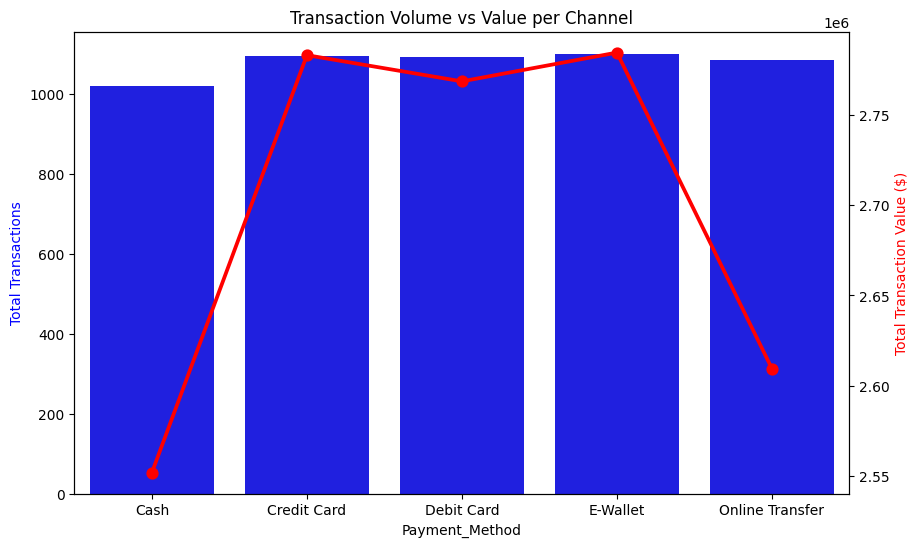

In [4]:
channel_perf = df.groupby('Payment_Method').agg(
    total_tx=('Transaction_ID','count'),
    total_value=('Transaction_Amount','sum'),
    avg_value=('Transaction_Amount','mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(10,6))
sns.barplot(x='Payment_Method', y='total_tx', data=channel_perf, ax=ax1, color='blue')
ax1.set_ylabel('Total Transactions', color='blue')
ax2 = ax1.twinx()
sns.pointplot(x='Payment_Method', y='total_value', data=channel_perf, ax=ax2, color='red', markers='o')
ax2.set_ylabel('Total Transaction Value ($)', color='red')
plt.title("Transaction Volume vs Value per Channel")
plt.show()

> The graph above shows that e-wallets and credit cards are the most important transaction channels, characterized by high total transactions and total transaction value. This indicates that these two channels are not only frequently used by customers but also process large amounts of transactions.

> Conversely, online transfers have a relatively high total transaction volume but a much lower total transaction value. This finding suggests that although this channel remains widely used, the nominal transactions processed tend to be smaller, resulting in a lower business value contribution compared to other channels.

### 4.2 Time-Based Patterns per Channel

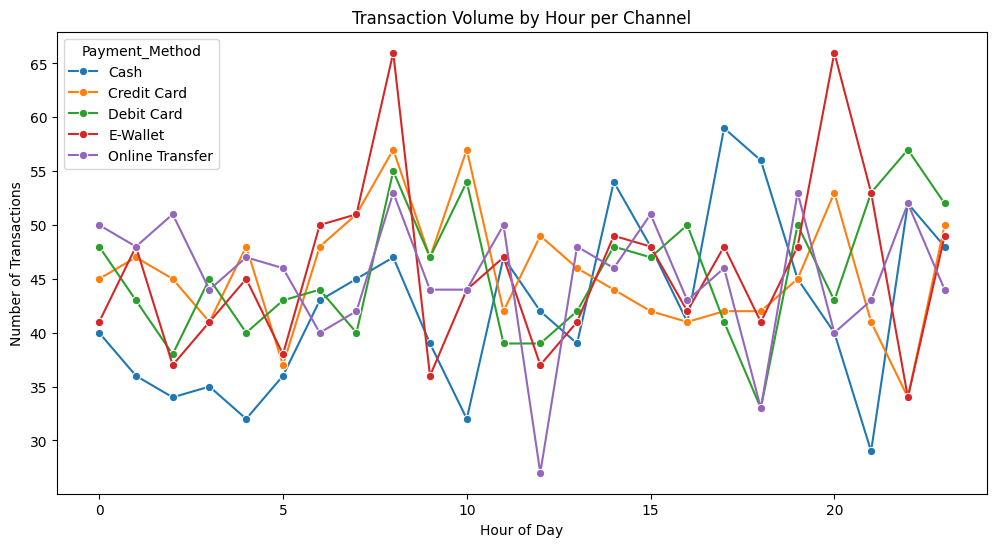

In [5]:
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])
df['hour'] = df['Transaction_Date'].dt.hour

hourly_channel = df.groupby(['hour','Payment_Method'])['Transaction_ID'].count().reset_index()
plt.figure(figsize=(12,6))
sns.lineplot(data=hourly_channel, x='hour', y='Transaction_ID', hue='Payment_Method', marker='o')
plt.title("Transaction Volume by Hour per Channel")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")
plt.show()

> The graph above shows the hourly transaction volume for each channel. Transaction activity is uneven throughout the day, with each channel experiencing high volumes at specific times. Transaction activity peaks in the morning, around 8:00–10:00 AM, and then increases again in the evening, around 8:00 PM.

> This pattern provides important insight for banking teams to ensure system stability and readiness during high-traffic hours, while also monitoring low-volume hours, such as early morning, between 1:00–5:00 AM.

> Strikingly, the E-Wallet channel exhibits the highest peak transaction volume compared to other channels, with approximately 65 transactions occurring at 8:00 AM, with a subsequent increase in the evening.

## 5. Feature Engineering

### 5.1 Transaction Value Segmentation

/var/folders/rh/my8c389x4kz3rv_sh8b0p2tr0000gn/T/ipykernel_8410/3568436345.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  value_seg_channel = df.groupby(['tx_value_bin','Payment_Method'])['Transaction_ID'].count().unstack().fillna(0)


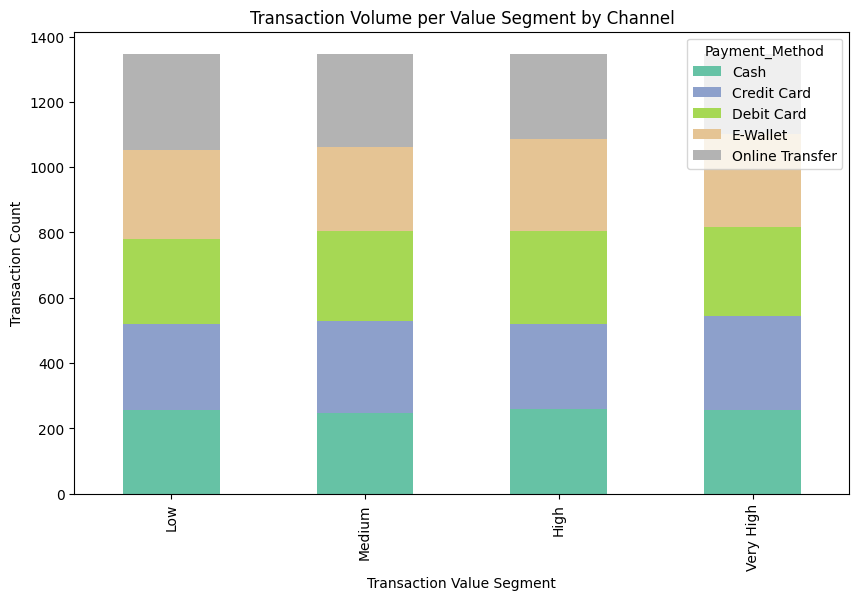

In [6]:
df['tx_value_bin'] = pd.qcut(df['Transaction_Amount'], 4, labels=['Low','Medium','High','Very High'])

value_seg_channel = df.groupby(['tx_value_bin','Payment_Method'])['Transaction_ID'].count().unstack().fillna(0)

value_seg_channel.plot(kind='bar', stacked=True, figsize=(10,6), colormap='Set2')
plt.title("Transaction Volume per Value Segment by Channel")
plt.xlabel("Transaction Value Segment")
plt.ylabel("Transaction Count")
plt.show()

> This graph shows that transaction volumes in each value segment are relatively balanced across payment channels. This indicates that there is no significant dependence on any particular channel for low or high value transactions. From a banking perspective, this demonstrates that all channels play an equally important role in supporting customer transaction activity across various value ranges.

### 5.2 Customer Demographics per Channel

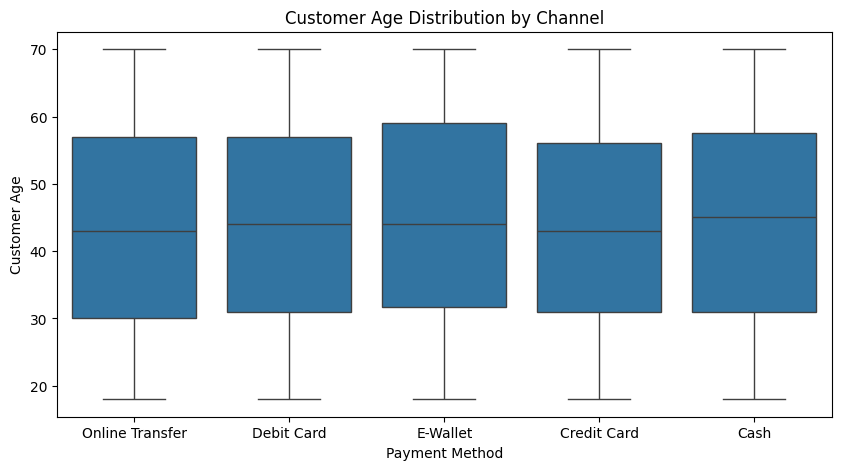

In [7]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Payment_Method', y='Customer_Age')
plt.title("Customer Age Distribution by Channel")
plt.xlabel("Payment Method")
plt.ylabel("Customer Age")
plt.show()

> The age distribution of customers across all payment channels appears relatively uniform, indicating that age is not a major factor in choosing a transaction method. This indicates that all channels are widely accepted by various age groups.

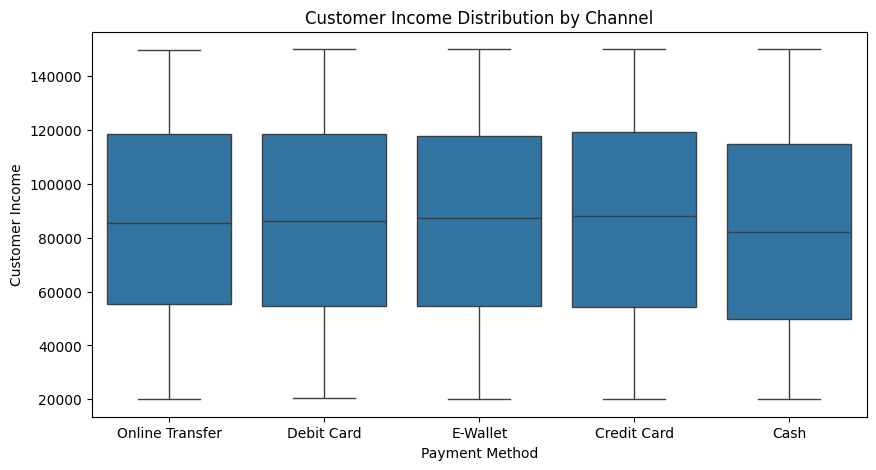

In [8]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Payment_Method', y='Customer_Income')
plt.title("Customer Income Distribution by Channel")
plt.xlabel("Payment Method")
plt.ylabel("Customer Income")
plt.show()

> The boxplot above shows that the median income of customers using Cash is slightly lower than other payment channels, while Credit Card, Debit Card, E-Wallet, and Online Transfer have a relatively similar income distribution. This insight indicates that non-cash channels tend to be used by customers with comparable income levels, while Cash usage is more dominant in slightly lower income segments. Although the difference is not significant, this pattern still indicates differences in channel preferences based on income level. From a banking perspective, this finding can be the basis for encouraging the adoption of non-cash payments through education and providing incentives to the Cash-using customer segment.

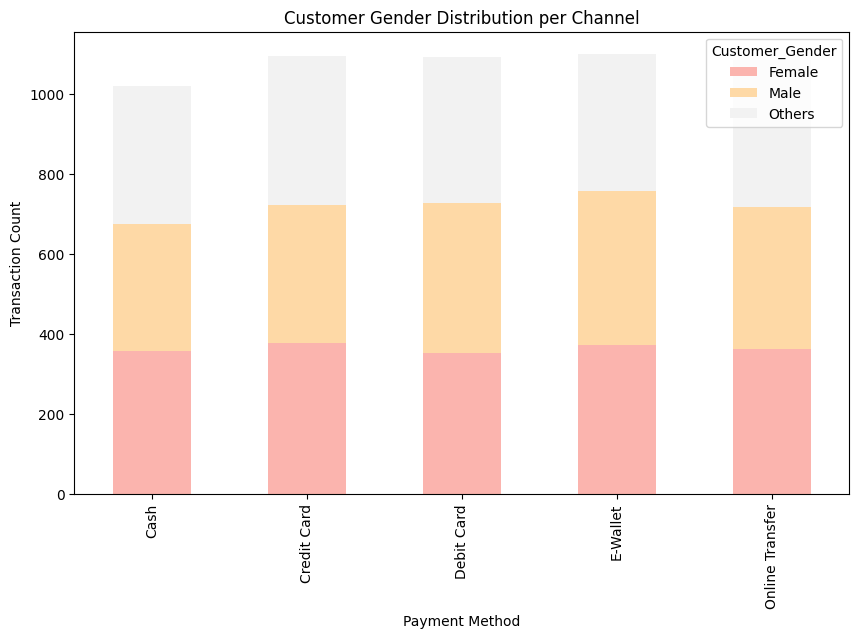

In [9]:
gender_channel = df.groupby(['Payment_Method','Customer_Gender'])['Transaction_ID'].count().unstack().fillna(0)
gender_channel.plot(kind='bar', stacked=True, figsize=(10,6), colormap='Pastel1')
plt.title("Customer Gender Distribution per Channel")
plt.xlabel("Payment Method")
plt.ylabel("Transaction Count")
plt.show()

> Gender distribution across payment channels appears relatively uniform, indicating that gender is not a major differentiator in transaction method preferences.

## 6. Fraud & Failed Transaction Analysis

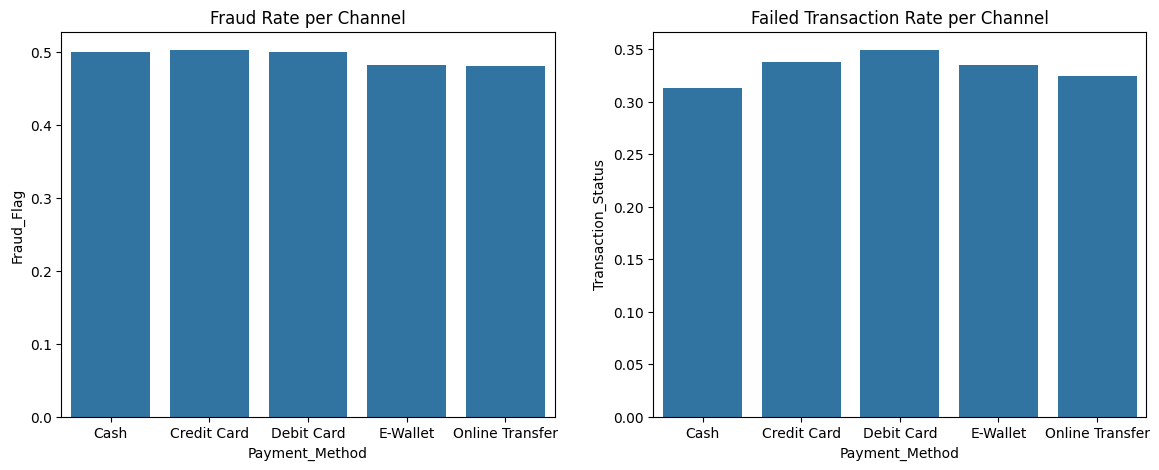

In [10]:
fraud_summary = df.groupby('Payment_Method')['Fraud_Flag'].apply(lambda x: (x=='Yes').mean()).reset_index()
failed_summary = df.groupby('Payment_Method')['Transaction_Status'].apply(lambda x: (x=='Failed').mean()).reset_index()

fig, ax = plt.subplots(1,2, figsize=(14,5))
sns.barplot(x='Payment_Method', y='Fraud_Flag', data=fraud_summary, ax=ax[0])
ax[0].set_title("Fraud Rate per Channel")
sns.barplot(x='Payment_Method', y='Transaction_Status', data=failed_summary, ax=ax[1])
ax[1].set_title("Failed Transaction Rate per Channel")
plt.show()

> The fraud rate graph per channel shows that e-wallets and online transfers have slightly lower fraud rates than cash, credit cards, and debit cards, although the difference is not significant. Meanwhile, cash, credit cards, and debit cards have relatively similar fraud rates, indicating that fraud risk is fairly evenly distributed across channels and not concentrated in any one payment method. This confirms that all channels still require consistent fraud control, rather than a restrictive approach to a single channel.

> In terms of operational risk, the failed transactions graph shows that debit cards have a slightly higher transaction failure rate than other channels, while cash and online transfers tend to be slightly more stable. However, the differences are not significant, suggesting that transaction failures reflect technical and operational system issues rather than customer behavior. This insight leads to a recommendation that banks prioritize improving infrastructure stability, particularly in the debit card channel, while maintaining comprehensive risk monitoring across all payment channels.

## 7. Channel Efficiency Scoring

In [11]:
channel_cost = {
    'Cash': 0.25,
    'Credit Card': 0.15,
    'Debit Card': 0.12,
    'E-Wallet': 0.05,
    'Online Transfer': 0.08
}

channel_perf = df.groupby('Payment_Method').agg(
    total_tx=('Transaction_ID','count'),
    total_value=('Transaction_Amount','sum'),
    avg_value=('Transaction_Amount','mean')
).reset_index()

channel_perf['cost_per_tx'] = channel_perf['Payment_Method'].map(channel_cost)
channel_perf['efficiency'] = channel_perf['avg_value'] / channel_perf['cost_per_tx']

channel_perf = channel_perf.merge(
    fraud_summary.rename(columns={'Fraud_Flag':'fraud_rate'}),
    on='Payment_Method'
)

channel_perf = channel_perf.merge(
    failed_summary.rename(columns={'Transaction_Status':'failed_rate'}),
    on='Payment_Method'
)

channel_perf['channel_score'] = (
    channel_perf['efficiency']
    * (1 - channel_perf['fraud_rate'])
    * (1 - channel_perf['failed_rate'])
)

channel_perf = channel_perf.sort_values('channel_score', ascending=False)
channel_perf

,Payment_Method,total_tx,total_value,avg_value,cost_per_tx,efficiency,fraud_rate,failed_rate,channel_score
3,E-Wallet,1100,2784491.51,2531.355918,0.05,50627.118364,0.482727,0.334545,17426.941996
4,Online Transfer,1085,2609528.10,2405.095023,0.08,30063.687788,0.481106,0.324424,10538.896653
2,Debit Card,1091,2768562.71,2537.637681,0.12,21146.980675,0.499542,0.349221,6887.313608
1,Credit Card,1094,2783058.42,2543.929086,0.15,16959.527239,0.502742,0.337294,5588.767002
0,Cash,1019,2551913.80,2504.331501,0.25,10017.326006,0.499509,0.313052,3444.067510


> Channel performance analysis shows that e-wallets are the most optimal channel for business, driven by very low operational costs and average transaction values comparable to other channels. Although fraud and transaction failure rates are not the lowest, high cost efficiency results in e-wallets achieving the highest channel score compared to other payment channels.

> Conversely, the cash channel ranks at the bottom due to significantly higher operational costs, without compensation in the form of lower transaction values or risks. Meanwhile, credit cards and debit cards rank in the middle, indicating that while still relevant in terms of volume and value, card-based channels face challenges in terms of cost and operational risk. These findings indicate that banking strategies should prioritize strengthening digital channels to improve overall operational efficiency.

## 8. Channel Contribution Analysis

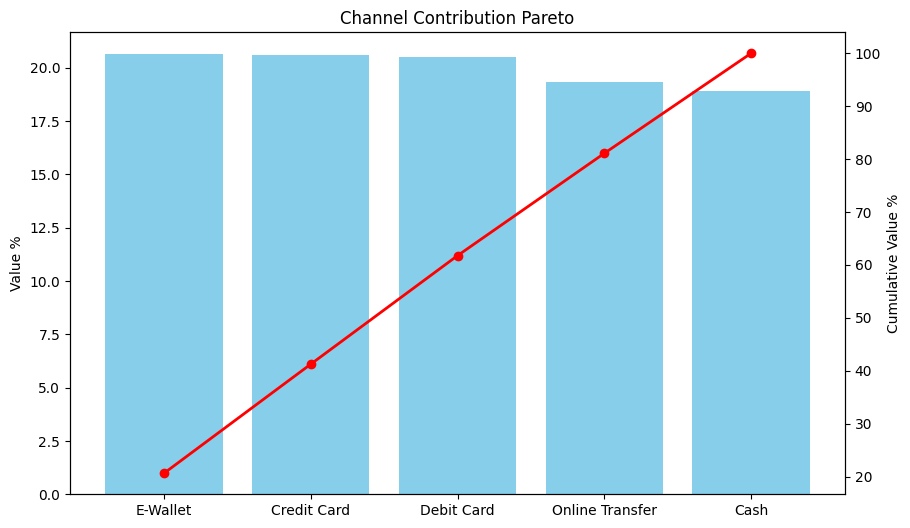

In [12]:
channel_perf['volume_pct'] = channel_perf['total_tx'] / channel_perf['total_tx'].sum() * 100
channel_perf['value_pct'] = channel_perf['total_value'] / channel_perf['total_value'].sum() * 100

channel_perf_sorted = channel_perf.sort_values('total_value', ascending=False)
channel_perf_sorted['cum_value_pct'] = channel_perf_sorted['value_pct'].cumsum()

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(channel_perf_sorted['Payment_Method'], channel_perf_sorted['value_pct'], color='skyblue')
ax2 = ax.twinx()
ax2.plot(channel_perf_sorted['Payment_Method'], channel_perf_sorted['cum_value_pct'], color='red', marker='o', linewidth=2)
ax.set_ylabel('Value %')
ax2.set_ylabel('Cumulative Value %')
plt.title("Channel Contribution Pareto")
plt.show()

> Transaction value contributions across payment channels are relatively even, with no single channel significantly dominating. The nearly linear increase in the cumulative line indicates that each channel plays a balanced role in shaping the total transaction value.

## 9. Scenario & Sensitivity Analysis

In [13]:
df_scenario = df.copy()

df_scenario.loc[df_scenario['Payment_Method'] == 'Cash', 'Payment_Method'] = 'E-Wallet'

scenario_perf = df_scenario.groupby('Payment_Method').agg(
    total_tx=('Transaction_ID','count'),
    total_value=('Transaction_Amount','sum')
).reset_index()

scenario_perf

,Payment_Method,total_tx,total_value
0,Credit Card,1094,2783058.42
1,Debit Card,1091,2768562.71
2,E-Wallet,2119,5336405.31
3,Online Transfer,1085,2609528.10


> The scenario highlights that cash transactions represent a substantial share of total transaction value, and fully shifting them to E-Wallet would significantly increase channel concentration, requiring careful risk and capacity considerations.

> Cash is not a small channel, and eliminating it is not just about moving transactions, but moving the risk and burden on the system.

## 10. Final Summary Table

In [14]:
final_summary = channel_perf[[
    'Payment_Method',
    'total_tx',
    'total_value',
    'efficiency',
    'fraud_rate',
    'failed_rate',
    'channel_score',
    'volume_pct',
    'value_pct'
]]

final_summary = final_summary.sort_values('channel_score', ascending=False)
final_summary

,Payment_Method,total_tx,total_value,efficiency,fraud_rate,failed_rate,channel_score,volume_pct,value_pct
3,E-Wallet,1100,2784491.51,50627.118364,0.482727,0.334545,17426.941996,20.411950,20.629600
4,Online Transfer,1085,2609528.10,30063.687788,0.481106,0.324424,10538.896653,20.133605,19.333340
2,Debit Card,1091,2768562.71,21146.980675,0.499542,0.349221,6887.313608,20.244943,20.511588
1,Credit Card,1094,2783058.42,16959.527239,0.502742,0.337294,5588.767002,20.300612,20.618983
0,Cash,1019,2551913.80,10017.326006,0.499509,0.313052,3444.067510,18.908888,18.906490


## 11. Actionable Recommendations

> Focus on developing e-wallets as the primary channel, as they offer the highest cost efficiency and contribute the largest transaction value, while still strengthening system capacity and risk monitoring to avoid overconcentration.

> Optimize operational stability during peak transaction hours (8:00-10:00 AM and 8:00 PM) and improve the reliability of debit cards, which have a relatively higher failure rate, to reduce operational risk without compromising the customer experience.